In [1]:
import numpy as np
from pathlib import Path
import importlib
import re

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Setup according to the performances dict structure

working_dir = Path("/home/kinichen/projects/def-jbpoline/kinichen/dFC")
output_root = working_dir / "sample_data" / "hybrid"
output_root.mkdir(parents=True, exist_ok=True)

performances = np.load(
    working_dir / output_root / "ALL_ML_SCORES_real.npy", allow_pickle=True
).item()
# print(performances.keys())

metric = "SVM balanced accuracy"
embedding = "PLS"
group = "test"

tasks = performances["task"]
methods = performances["dFC method"]
runs = performances["run"]

all_embeddings = performances["embedding"]
all_groups = performances["group"]
all_metric_scores = performances[metric]

print(f"All methods: {methods}")
print(f"All tasks: {tasks}")
print(f"All runs: {runs}")
print(f"All embeddings: {all_embeddings}")
print(f"All groups: {all_groups}")
print(f"All metric scores: {all_metric_scores}")

All methods: ['DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DerivativeWeightedWindow', 'DiscreteHMM', 'DiscreteHMM', 'DiscreteHMM', 'DiscreteHMM', 'DiscreteHMM', 'DiscreteHMM', 

In [3]:
# Get a list of the hybrid methods. Only these will be plotted.
hybrid_methods = set([method for method in methods if "hybrid" in method.lower()])
print(f"Hybrid methods: {hybrid_methods}")
print(f"Number of hybrid methods: {len(hybrid_methods)}")

Hybrid methods: {'AdaptiveRobustDifferential_hybrid_ensemble', 'EdgeRandomReservoir_hybrid_ensemble', 'ChangepointRobustExp_hybrid', 'AdaptiveQuantumReservoir_hybrid', 'RandomFourierKalman_hybrid', 'DifferentialEdgeKalman_hybrid', 'EdgeStftQuantum_hybrid', 'DccChangepointSparse_hybrid', 'DccEdgeExponential_hybrid', 'MultiscaleDccKalman_hybrid', 'StftQuantumSparse_hybrid_ensemble', 'ReservoirEdgeDcc_hybrid', 'EdgeKalmanExp_hybrid_ensemble', 'AdaptiveEdgeKalman_hybrid', 'RobustVolatilitySliding_hybrid_ensemble', 'DccKalmanVolatility_hybrid_ensemble', 'QuantumRandomExp_hybrid', 'RobustSparseEdge_hybrid', 'StftEdgeAdaptive_hybrid_ensemble', 'RobustDifferentialStft_hybrid', 'StftExpKalman_hybrid', 'SparseDccExp_hybrid_ensemble', 'SlidingVolatilityDcc_hybrid', 'QuantumMultiscaleKalman_hybrid_ensemble', 'KalmanReservoirMultiscale_hybrid', 'ReservoirChangepointRobust_hybrid_ensemble', 'AdaptiveRandomSparse_hybrid', 'VolatilityAdaptiveEdge_hybrid', 'ChangepointMultiscaleExp_hybrid_ensemble', 'A

In [4]:
# Filter for scores that have a specific embedding, group, and method (only hybrids) using zip,
# and keep the corresponding task, dFC method, and run labels for each score
filtered_rows = [
    (method, score)
    for emb, grp, task, method, run, score in zip(
        all_embeddings, all_groups, tasks, methods, runs, all_metric_scores
    )
    if emb == embedding and grp == group and method in hybrid_methods
]
print(filtered_rows)

[('VolatilityAdaptiveEdge_hybrid', 0.6454806707864877), ('VolatilityAdaptiveEdge_hybrid', 0.5663969663078429), ('VolatilityAdaptiveEdge_hybrid', 0.7610792249202846), ('VolatilityAdaptiveEdge_hybrid', 0.662266204978883), ('VolatilityAdaptiveEdge_hybrid', 0.7599870889344573), ('VolatilityAdaptiveEdge_hybrid', 0.6663763862371532), ('VolatilityAdaptiveEdge_hybrid', 0.6416803805721172), ('VolatilityAdaptiveEdge_hybrid', 0.6704527557231399), ('StftQuantumSparse_hybrid_ensemble', 0.564740055940417), ('StftQuantumSparse_hybrid_ensemble', 0.5526807509049394), ('StftQuantumSparse_hybrid_ensemble', 0.6635824696458013), ('StftQuantumSparse_hybrid_ensemble', 0.5866405468272842), ('StftQuantumSparse_hybrid_ensemble', 0.66315988523735), ('StftQuantumSparse_hybrid_ensemble', 0.6322675917678495), ('StftQuantumSparse_hybrid_ensemble', 0.5870864443474897), ('StftQuantumSparse_hybrid_ensemble', 0.5902565024384144), ('DccChangepointSparse_hybrid', 0.5169518089344577), ('DccChangepointSparse_hybrid', 0.5334

In [5]:
# Get and add the COMPONENTS and HYBRID_RULE class attributes from each hybrid method class to the filtered rows


def method_to_module_name(method_name):
    """Convert method names like ChangepointRobustExp_hybrid to changepoint_robust_exp_hybrid."""
    return re.sub(r"(?<!^)(?=[A-Z])", "_", method_name).lower()


hybrid_rows = []

for method, score in filtered_rows:
    module_name = method_to_module_name(method)
    script_path = working_dir / "pydfc" / "dfc_methods" / f"{module_name}.py"

    if not script_path.exists():
        print(f"Script for method {method} not found at {script_path}.")
        hybrid_rows.append((method, score, None, None))
        continue

    hybrid_module = importlib.import_module(f"pydfc.dfc_methods.{module_name}")

    # The class name uses the upper-case snake-case module name.
    # Example: VolatilityAdaptiveEdge_hybrid -> VOLATILITY_ADAPTIVE_EDGE_HYBRID
    class_name = module_name.upper()
    hybrid_class = getattr(hybrid_module, class_name, None)
    hybrid_components = getattr(
        hybrid_class, "COMPONENTS", None
    )  # original method used to ensemble the hybrid

    hybrid_rule = getattr(hybrid_class, "HYBRID_RULE", None)
    # Many different names for hybrid_rule could be synonymous (same math/code operations),
    # so we need to unify them into one name
    if str(hybrid_rule) == "ensemble_mean":
        hybrid_rule = "mean"
    else:
        if "residual" in str(hybrid_rule):
            hybrid_rule = "residual"
        elif "sparse" in str(hybrid_rule):
            hybrid_rule = "sparse"
        elif (
            "kernel" in str(hybrid_rule)
            or "information" in str(hybrid_rule)
            or "spectral" in str(hybrid_rule)
        ):
            hybrid_rule = "kernel"
        elif (
            "change" in str(hybrid_rule)
            or "derivative" in str(hybrid_rule)
            or "volatility" in str(hybrid_rule)
        ):
            hybrid_rule = "change"
        else:
            if hybrid_rule == "adaptive_gate" or hybrid_rule == "state_modulated":
                hybrid_rule = "adaptive_gate"

    hybrid_rows.append((method, score, hybrid_components, hybrid_rule))

print(hybrid_rows)

[('VolatilityAdaptiveEdge_hybrid', 0.6454806707864877, ['VolatilityWeightedFC', 'AdaptiveExponentialWindow', 'EdgeCoactivation'], 'change'), ('VolatilityAdaptiveEdge_hybrid', 0.5663969663078429, ['VolatilityWeightedFC', 'AdaptiveExponentialWindow', 'EdgeCoactivation'], 'change'), ('VolatilityAdaptiveEdge_hybrid', 0.7610792249202846, ['VolatilityWeightedFC', 'AdaptiveExponentialWindow', 'EdgeCoactivation'], 'change'), ('VolatilityAdaptiveEdge_hybrid', 0.662266204978883, ['VolatilityWeightedFC', 'AdaptiveExponentialWindow', 'EdgeCoactivation'], 'change'), ('VolatilityAdaptiveEdge_hybrid', 0.7599870889344573, ['VolatilityWeightedFC', 'AdaptiveExponentialWindow', 'EdgeCoactivation'], 'change'), ('VolatilityAdaptiveEdge_hybrid', 0.6663763862371532, ['VolatilityWeightedFC', 'AdaptiveExponentialWindow', 'EdgeCoactivation'], 'change'), ('VolatilityAdaptiveEdge_hybrid', 0.6416803805721172, ['VolatilityWeightedFC', 'AdaptiveExponentialWindow', 'EdgeCoactivation'], 'change'), ('VolatilityAdaptive

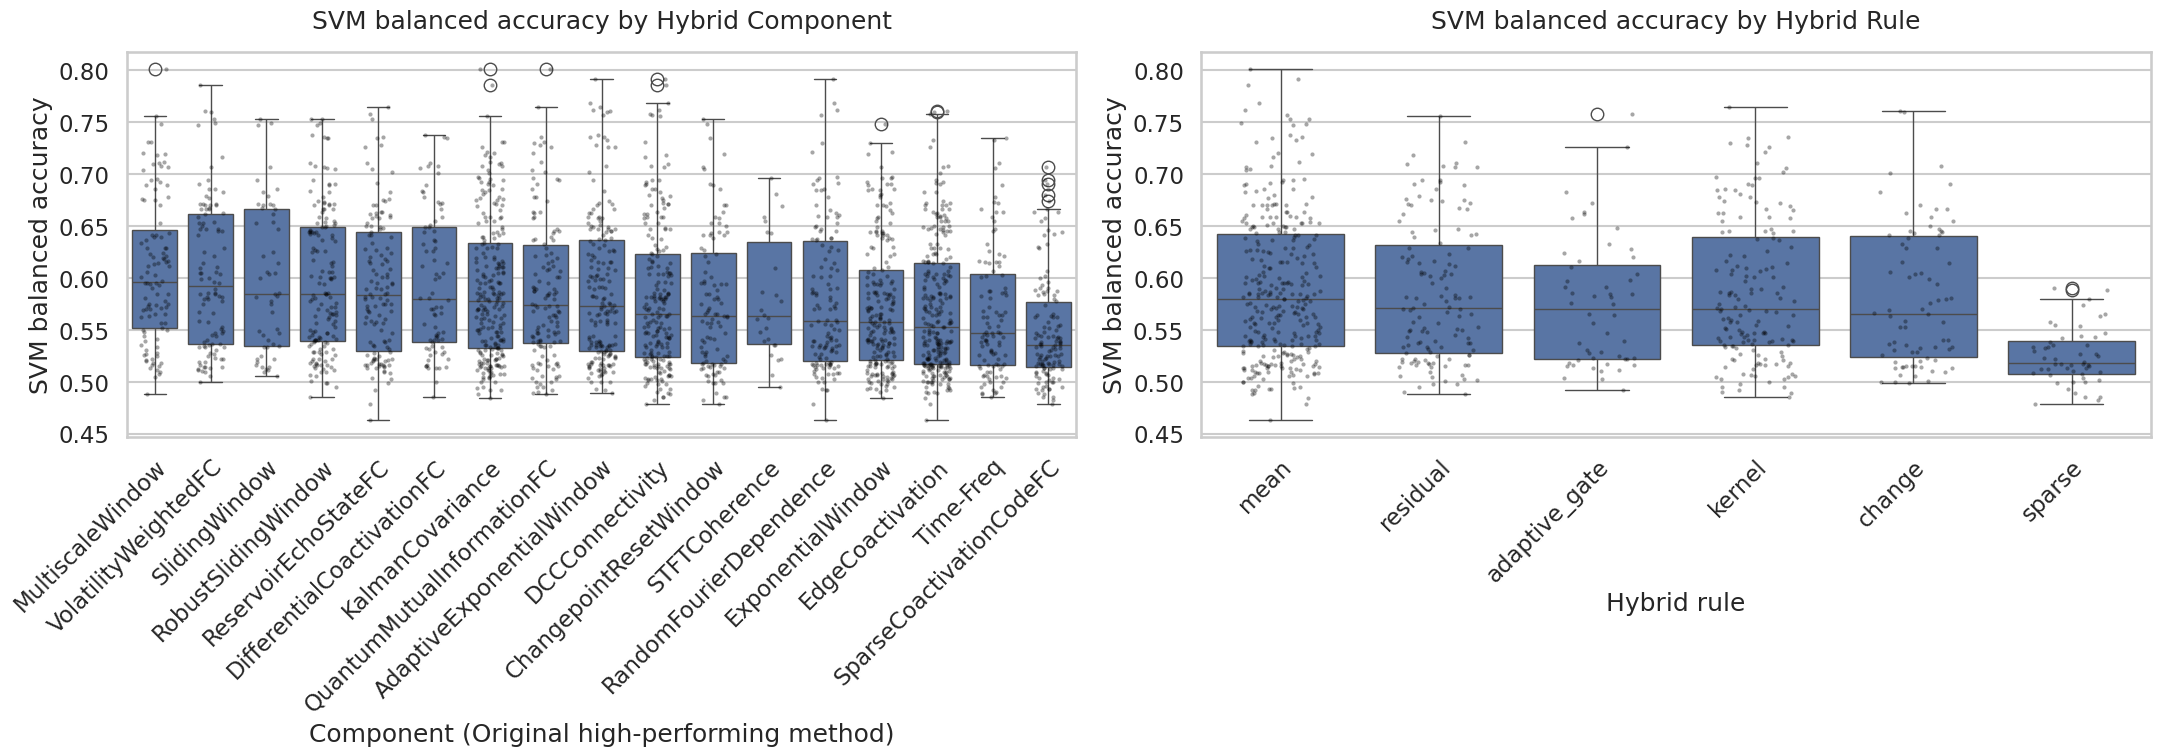

In [7]:
# Visualize the hybrid methods' scores as two box plots: one grouped by the components and one grouped by the hybrid rules.
# Each box plot will show the distribution of scores for each unique component and each unique hybrid rule.

# Build a tidy dataframe from hybrid_rows:
# hybrid_rows = [(method, score, components, hybrid_rule), ...]
hybrid_df = pd.DataFrame(
    hybrid_rows,
    columns=["method", "score", "components", "hybrid_rule"],
)

# One row per component, because each hybrid method can have multiple components.
component_df = (
    hybrid_df.dropna(subset=["components"])
    .explode("components")
    .rename(columns={"components": "component"})
)
# display(component_df)

# Keep only rows with a rule.
rule_df = hybrid_df.dropna(subset=["hybrid_rule"])

# Sort groups by median score for easier reading.
component_order = (
    component_df.groupby("component")["score"].median().sort_values(ascending=False).index
)
rule_order = (
    rule_df.groupby("hybrid_rule")["score"].median().sort_values(ascending=False).index
)

sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.boxplot(
    data=component_df,
    x="component",
    y="score",
    order=component_order,
    ax=axes[0],
)
sns.stripplot(
    data=component_df,
    x="component",
    y="score",
    order=component_order,
    color="black",
    alpha=0.35,
    size=3,
    jitter=0.25,
    ax=axes[0],
)
axes[0].set_title(f"{metric} by Hybrid Component", y=1.04)
axes[0].set_xlabel("Component (Original high-performing method)")
axes[0].set_ylabel(metric)
axes[0].set_xticks(range(len(component_order)))
axes[0].set_xticklabels(
    component_order,
    rotation=45,
    ha="right",
    rotation_mode="anchor",
)

sns.boxplot(
    data=rule_df,
    x="hybrid_rule",
    y="score",
    order=rule_order,
    ax=axes[1],
)
sns.stripplot(
    data=rule_df,
    x="hybrid_rule",
    y="score",
    order=rule_order,
    color="black",
    alpha=0.35,
    size=3,
    jitter=0.25,
    ax=axes[1],
)
axes[1].set_title(f"{metric} by Hybrid Rule", y=1.04)
axes[1].set_xlabel("Hybrid rule")
axes[1].set_ylabel(metric)
axes[1].set_xticks(range(len(rule_order)))
axes[1].set_xticklabels(
    rule_order,
    rotation=45,
    ha="right",
    rotation_mode="anchor",
)

plt.tight_layout()
plt.show()